In [3]:
import yfinance as yf
import statsmodels.api as sm
import numpy as np
import pandas as pd
import os

In [4]:
var = pd.read_csv("研究變數資料_wk.csv",index_col=0,parse_dates=True)

In [6]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss

# 定義檢測平穩性的函數
def check_stationarity(series):
    series = series.dropna()  # 移除 NaN 值
    adf_result = adfuller(series)
    kpss_result = kpss(series, regression='c')

    adf_p = adf_result[1]
    kpss_p = kpss_result[1]

    # 判斷平穩性
    if adf_p < 0.05 and kpss_p > 0.05:
        conclusion = "Likely Stationary (Mean-Reverting)"
    elif adf_p > 0.05 and kpss_p < 0.05:
        conclusion = "Trend-Stationary (Needs Detrending)"
    elif adf_p < 0.05 and kpss_p < 0.05:
        conclusion = "Contradictory Results"
    else:
        conclusion = "Likely Non-Stationary"

    return {
        "ADF p-value": adf_p,
        "KPSS p-value": kpss_p,
        "Conclusion": conclusion
    }

# 變數列表
variables = ['general_esg_interest', 'esg_investment', 'renewable_energy',
       'climate_topics',"vix", 'gp']


# 進行檢測並存儲結果
results = {va: check_stationarity(var[va]) for va in variables if va in var}

# 轉換為 DataFrame
stationarity_df = pd.DataFrame.from_dict(results, orient='index')

# 顯示結果
print(stationarity_df)


                       ADF p-value  KPSS p-value  \
general_esg_interest  7.821086e-27           0.1   
esg_investment        4.393293e-12           0.1   
renewable_energy      1.511581e-09           0.1   
climate_topics        3.953842e-27           0.1   
vix                   3.943236e-17           0.1   
gp                    6.208457e-19           0.1   

                                              Conclusion  
general_esg_interest  Likely Stationary (Mean-Reverting)  
esg_investment        Likely Stationary (Mean-Reverting)  
renewable_energy      Likely Stationary (Mean-Reverting)  
climate_topics        Likely Stationary (Mean-Reverting)  
vix                   Likely Stationary (Mean-Reverting)  
gp                    Likely Stationary (Mean-Reverting)  


C:\Users\USER\AppData\Local\Temp\ipykernel_21336\1723218567.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression='c')
C:\Users\USER\AppData\Local\Temp\ipykernel_21336\1723218567.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression='c')
C:\Users\USER\AppData\Local\Temp\ipykernel_21336\1723218567.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression='c')
C:\Users\USER\AppData\Local\Temp\ipykernel_21336\1723218567.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-u

In [23]:
import pandas as pd
import numpy as np
import yfinance as yf
from statsmodels.tsa.api import VAR
import warnings

other_vars = ['general_esg_interest', 'esg_investment', 'renewable_energy', 'climate_topics']
target_var = 'gp'
control_var = 'vix' # 控制變數

required_cols = other_vars + [target_var, control_var]

# 檢查 'var' 是否真的存在
if 'var' not in locals() or not isinstance(var, pd.DataFrame):
    print("錯誤：DataFrame 'var' 未定義。請在執行此代碼前先載入您的資料。")
else:
    # 檢查是否包含所有必要的欄位
    missing_cols = [col for col in required_cols if col not in var.columns]
    if missing_cols:
        print(f"錯誤：DataFrame 'var' 中缺少以下必要的欄位：{', '.join(missing_cols)}")
    else:
        print(f"DataFrame 'var' 已準備就緒 (N={len(var)})。")
        print(f"將為 'gp' 與各變數 (並控制 '{control_var}') 執行 VAR：{', '.join(other_vars)}\n")
        
        all_summaries = {}
        all_results = {}
        
        for v in other_vars:
            # 3 變數系統: [v, target_var, control_var]
            print(f"--- 開始執行 VAR：'{v}' vs '{target_var}' (控制 '{control_var}') ---")
            
            try:
                # 1. 選取三個變數
                df_temp = var[[v, target_var, control_var]].copy()
                
                # 2. 確保資料是數值型態，並移除 NA
                for col in df_temp.columns:
                    df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')
                
                df_temp = df_temp.dropna()
                
                # 3. 檢查是否有足夠的資料
                if len(df_temp) < 30: 
                    print(f"去除 NA 後資料點不足 (n={len(df_temp)})，無法執行 VAR。至少需要 30 個觀測值。")
                    continue

                # 4. 建立 VAR 模型
                # *** 根據您的確認，已移除差分步驟 ***
                model = VAR(df_temp) 
                
                # 5. 擬合模型
                # 讓 statsmodels 自動根據 AIC 選擇最佳 lag
                try:
                    results = model.fit(ic='aic', verbose=False)
                    lag_order = results.k_ar
                    print(f"資料已確認為定態。")
                    print(f"選擇的 lag 階數 (AIC): {lag_order}")
                    
                    # 6. 儲存並印出模型摘要
                    summary = results.summary()
                    all_summaries[v] = summary
                    all_results[v] = results
                    
                    print(f"\nVAR 模型摘要：'{v}' / '{target_var}' / '{control_var}' (定態資料)")
                    print(summary)
                    
                except Exception as e:
                    # 捕捉擬合時可能發生的錯誤
                    print(f"為 '{v}' 擬合 VAR 模型時發生錯誤：{e}")

            except Exception as e:
                print(f"處理 '{v}' 時發生未預期錯誤：{e}")
            
            print(f"--- 完成 VAR：'{v}' vs '{target_var}' (控制 '{control_var}') ---\n")

        if not all_summaries:
            print("未成功生成任何 VAR 模型。")

print("\n" + "="*50)
print("所有分析執行完畢。")
print(f"提醒：模型已直接使用您提供的定態資料進行擬合。")
print(f"請檢查 'Results for equation {target_var}' (gp) 的部分，")
print(f"以查看 '{control_var}' (vix) 和其他變數的顯著性。")
print("="*50)

DataFrame 'var' 已準備就緒 (N=259)。
將為 'gp' 與各變數 (並控制 'vix') 執行 VAR：general_esg_interest, esg_investment, renewable_energy, climate_topics

--- 開始執行 VAR：'general_esg_interest' vs 'gp' (控制 'vix') ---
資料已確認為定態。
選擇的 lag 階數 (AIC): 3

VAR 模型摘要：'general_esg_interest' / 'gp' / 'vix' (定態資料)
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 01, Nov, 2025
Time:                     18:24:28
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -15.3118
Nobs:                     256.000    HQIC:                  -15.5602
Log likelihood:           953.349    FPE:                1.47834e-07
AIC:                     -15.7273    Det(Omega_mle):     1.31780e-07
--------------------------------------------------------------------
Results for equation general_esg_interest
                             coefficient       std. error           t-stat            prob

c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)



VAR 模型摘要：'renewable_energy' / 'gp' / 'vix' (定態資料)
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 01, Nov, 2025
Time:                     18:24:28
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -16.1546
Nobs:                     256.000    HQIC:                  -16.4029
Log likelihood:           1061.22    FPE:                6.36483e-08
AIC:                     -16.5700    Det(Omega_mle):     5.67364e-08
--------------------------------------------------------------------
Results for equation renewable_energy
                         coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------
const                      -0.001912         0.010020           -0.191           0.849
L1.renewable_energy        -0.208821         0.062944        

In [33]:
results_table = []
for v in other_vars:
    gc = all_results[v].test_causality('gp', [v], kind='f')
    results_table.append({
        'Variable': v,
        'F-stat': gc.test_statistic,
        'p-value': gc.pvalue,
        'Significant': '✅' if gc.pvalue < 0.05 else '❌'
    })

pd.DataFrame(results_table)


,Variable,F-stat,p-value,Significant
0,general_esg_interest,2.659572,0.047241,✅
1,esg_investment,4.116543,0.016671,✅
2,renewable_energy,0.453637,0.714801,❌
3,climate_topics,0.772887,0.462046,❌


Granger causality F-test. H_0: general_esg_interest does not Granger-cause gp. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         2.660          2.617   0.047 (3, 738)
----------------------------------------------


In [34]:
reverse_results = []
for v in ['general_esg_interest', 'esg_investment', 'renewable_energy', 'climate_topics']:
    gc_rev = all_results[v].test_causality(v, ['gp'], kind='f')
    reverse_results.append({
        'Variable': v,
        'F-stat': gc_rev.test_statistic,
        'p-value': gc_rev.pvalue,
        'Significant': '✅' if gc_rev.pvalue < 0.05 else '❌'
    })

pd.DataFrame(reverse_results)


,Variable,F-stat,p-value,Significant
0,general_esg_interest,0.923810,0.428776,❌
1,esg_investment,0.375614,0.686996,❌
2,renewable_energy,1.195174,0.310627,❌
3,climate_topics,1.103980,0.332087,❌



=== 脈衝反應圖 (Impulse Response Function) for 'general_esg_interest' ===


c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


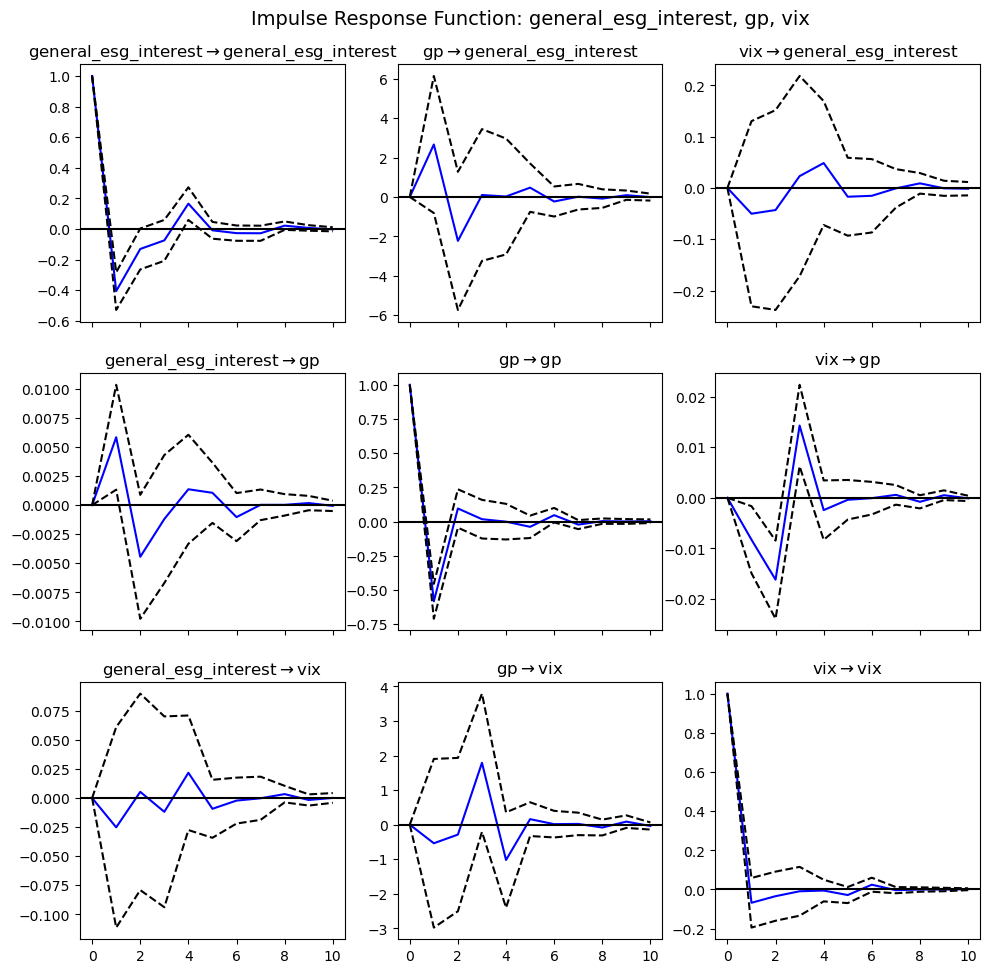


=== 脈衝反應圖 (Impulse Response Function) for 'esg_investment' ===


c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


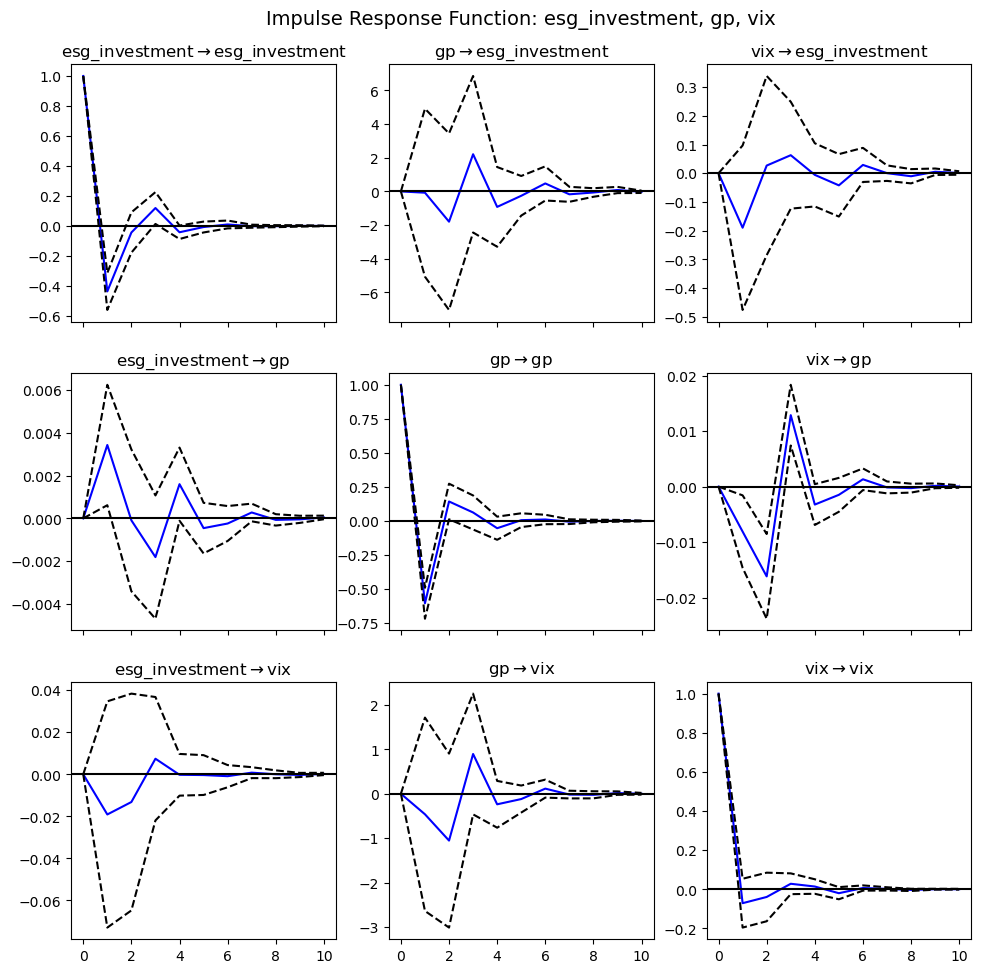


=== 脈衝反應圖 (Impulse Response Function) for 'renewable_energy' ===


c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


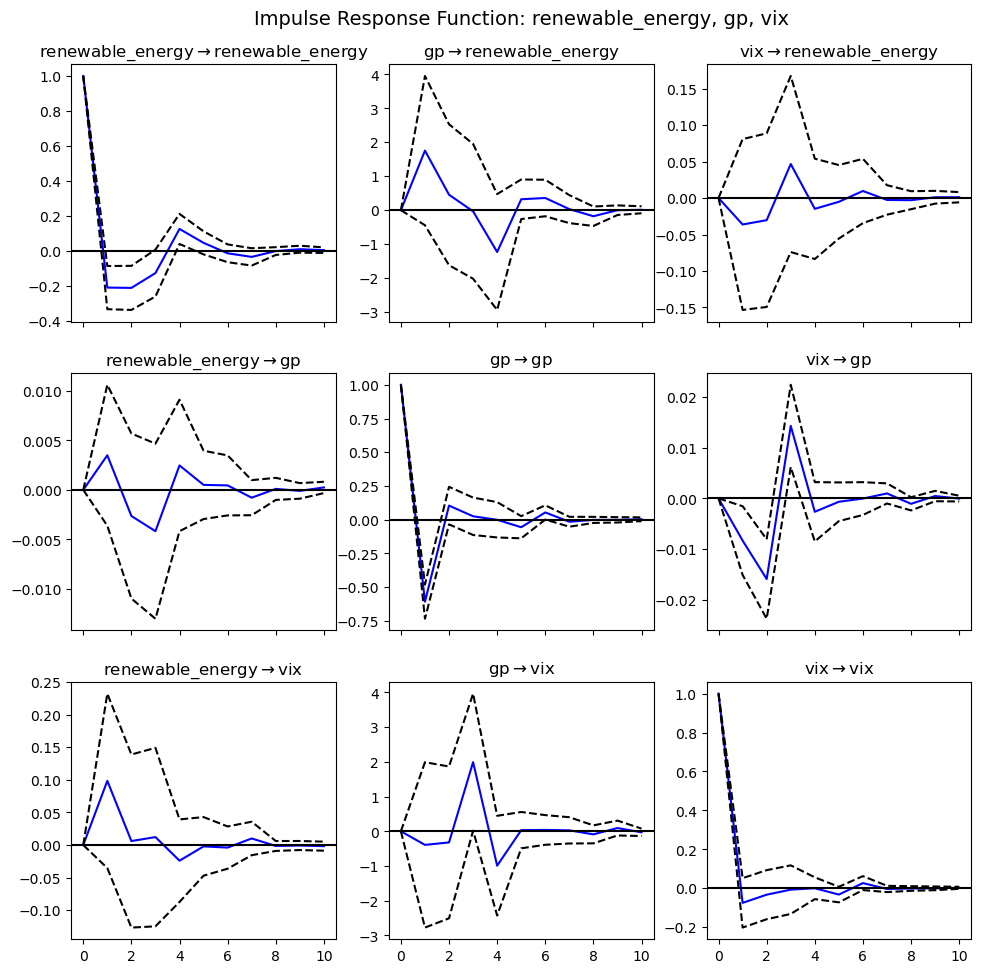


=== 脈衝反應圖 (Impulse Response Function) for 'climate_topics' ===


c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


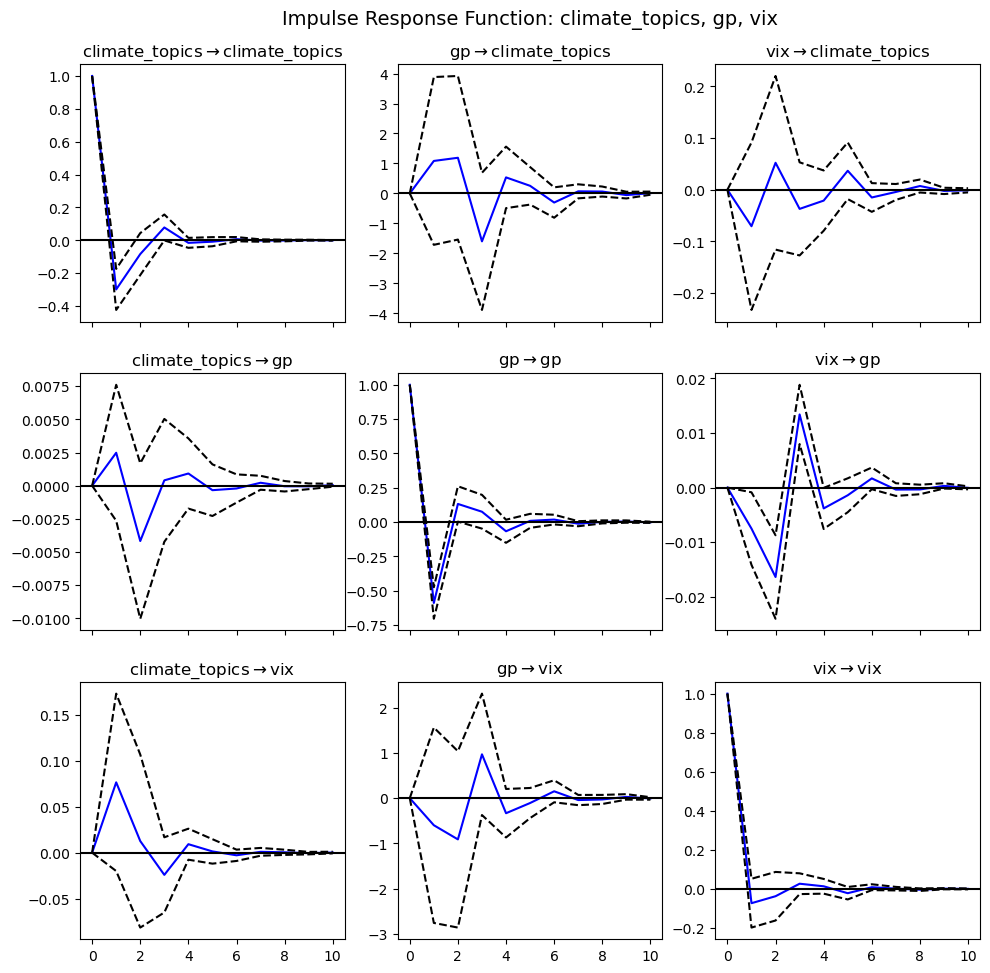

In [8]:
import matplotlib.pyplot as plt

if 'all_summaries' in locals() and all_summaries:
    for v in all_summaries.keys():
        print(f"\n=== 脈衝反應圖 (Impulse Response Function) for '{v}' ===")
        df_temp = var[[v, target_var, control_var]].dropna()
        model = VAR(df_temp)
        results = model.fit(ic='aic')
        
        # 產生 IRF
        irf = results.irf(10)  # 顯示 10 期的反應
        
        # 畫圖
        irf.plot(orth=False)
        plt.suptitle(f"Impulse Response Function: {v}, {target_var}, {control_var}", fontsize=14)
        plt.show()


c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\Lib\site

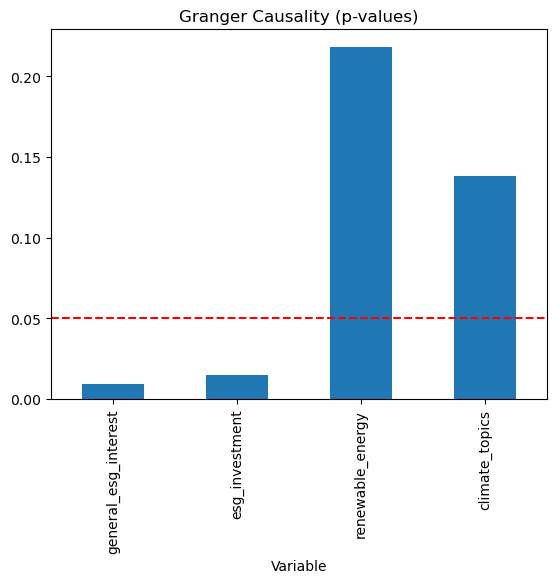

In [10]:
from statsmodels.tsa.stattools import grangercausalitytests

results_list = []
for v in other_vars:
    df_temp = var[[v, target_var, control_var]].dropna()
    model = VAR(df_temp)
    lag_order = model.fit(ic='aic').k_ar
    gc = grangercausalitytests(df_temp[[target_var, v]], maxlag=lag_order, verbose=False)
    p_values = [round(gc[i + 1][0]['ssr_chi2test'][1], 4) for i in range(lag_order)]
    results_list.append((v, min(p_values)))

gc_df = pd.DataFrame(results_list, columns=['Variable', 'Min_p_value'])
gc_df.plot.bar(x='Variable', y='Min_p_value', title='Granger Causality (p-values)', legend=False)
plt.axhline(0.05, color='r', linestyle='--')
plt.show()
